# Real Estate Buyer Segmentation & Investment Profiling

**Business Problem**

Parcl currently lacks a data-driven understanding of property buyers, investment motivations, geographic behavior, and financing patterns. Treating all buyers uniformly leads to inefficient marketing spend, generic property recommendations, and missed high-value opportunities.

**Methodology**

Using unsupervised learning (K-Means & Hierarchical Clustering), we process raw client data, evaluate optimal cluster metrics, and segment buyers into distinct behavioral personas (Global Investors, First-Time Buyers, Corporate Buyers, Luxury Investors).

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [18]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [19]:
df = pd.read_csv('clients.csv')

In [20]:
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset Loaded: 2000 rows, 12 columns


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


**Data Cleaning**

Real-world datasets often contain inconsistent formatting, missing entries, or duplicate records. In this step:


*  **Normalize Strings:** We strip excess whitespace and standardize text to lowercase across all categorical fields.
*   **Feature Engineering (age):** We convert date_of_birth into datetime format and derive the client's current age, which provides a quantitative metric for demographic analysis.

*  **Handle Missing Values:** Missing categorical values are imputed using the mode (most frequent value), while missing numeric values (like satisfaction_score or derived age) are imputed using the median.
*   **Deduplication:** We drop any duplicate client entries based on client_id.

In [21]:
# 1. Strip spaces and lower-case text columns
categorical_cols = ['client_type', 'gender', 'country', 'region', 'acquisition_purpose', 'loan_applied', 'referral_channel']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.lower()
        df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
# 2. Derive 'age' column from 'date_of_birth'
if 'date_of_birth' in df.columns:
    df['date_of_birth'] = pd.to_datetime(df['date_of_birth'], errors='coerce')
    current_year = datetime.now().year
    df['age'] = current_year - df['date_of_birth'].dt.year
    df['age'] = df['age'].fillna(df['age'].median())

In [23]:
# 3. Fill missing satisfaction scores
if 'satisfaction_score' in df.columns:
    df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())

In [24]:
# 4. Drop duplicate client IDs
df = df.drop_duplicates(subset=['client_id'])

print("Data cleaning complete!")
print(f"Cleaned dataset records: {len(df)}")

Data cleaning complete!
Cleaned dataset records: 2000


**Feature Encoding & Scaling Pipeline**

Machine learning algorithms rely on mathematical distances to cluster data. Therefore:

*   One-Hot Encoding: Converts categorical text features (client_type, region, country, etc.) into binary numerical indicators ($0$ or $1$).
*   Feature Scaling: Standardizes continuous numerical variables (age and satisfaction_score) using StandardScaler so that variables with larger ranges do not dominate distance metrics.

combine both transformations using ColumnTransformer into a unified feature matrix X_processed.



In [25]:
# Features to use for clustering
num_cols = ['age', 'satisfaction_score']
cat_cols = [c for c in categorical_cols if c in df.columns]

# Build Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

# Process data matrix for models
X_processed = preprocessor.fit_transform(df)

print(f"✅ Features Encoded & Scaled successfully! Feature Matrix Shape: {X_processed.shape}")

✅ Features Encoded & Scaled successfully! Feature Matrix Shape: (2000, 73)


**Clustering Model Selection & Evaluation**

Before fitting our final model, we must determine the optimal number of clusters ($K$). We evaluate K-Means across $K \in [2, 8]$ using two validation techniques:


1.   Elbow Method (WCSS / Inertia): Measures within-cluster variation. We look for an "elbow" point where adding more clusters yields diminishing returns.
2.   Silhouette Score: Quantifies how well-separated and cohesive the clusters are (higher values indicate better-defined clusters).


1.  Hierarchical Dendrogram: Visually displays nested hierarchical relationships to confirm structural cutoff levels.






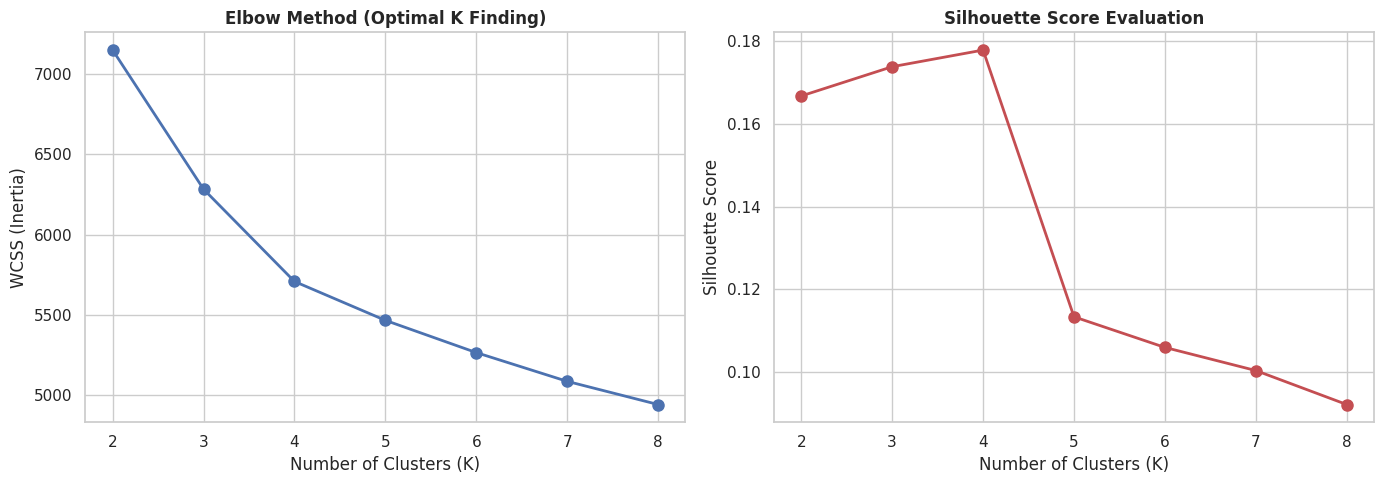

In [26]:
#  Evaluate Elbow Curve and Silhouette Scores for K=2 to 8
wcss = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_processed)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_processed, kmeans.labels_))

# Plot results side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
ax[0].plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
ax[0].set_title('Elbow Method (Optimal K Finding)', fontweight='bold')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('WCSS (Inertia)')

# Silhouette Score Plot
ax[1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax[1].set_title('Silhouette Score Evaluation', fontweight='bold')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

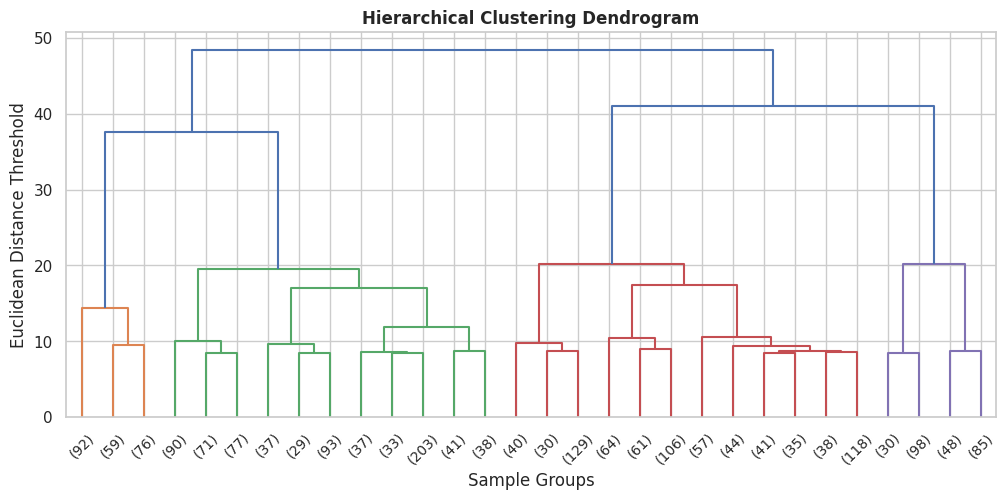

In [27]:
# Hierarchical Clustering Dendrogram Validation
plt.figure(figsize=(12, 5))
linked = linkage(X_processed, method='ward')
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=45)
plt.title('Hierarchical Clustering Dendrogram', fontweight='bold')
plt.xlabel('Sample Groups')
plt.ylabel('Euclidean Distance Threshold')
plt.show()

**Model Training & Buyer Persona Assignment**

Based on our evaluation metrics, we select $K=4$ clusters. We fit the final K-Means model and map the numerical cluster labels to Parcl's recommended buyer personas:

*   C1: Global Investors
*   C2: First-Time Buyers

*   C3: Corporate Buyers
*   C4: Luxury Investors

*Finally, we output an aggregate summary table displaying the client distribution, average age, and satisfaction score per segment.*





In [30]:
# Train Final K-Means Model (K=4)
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster_id'] = kmeans_final.fit_predict(X_processed)

# Assign Project Buyer Types
segment_map = {
    0: 'C1: Global Investors',
    1: 'C2: First-Time Buyers',
    2: 'C3: Corporate Buyers',
    3: 'C4: Luxury Investors'
}

df['segment_name'] = df['cluster_id'].map(segment_map)

# View Segment Breakdown
summary = df.groupby('segment_name').agg(
    Total_Clients=('client_id', 'count'),
    Avg_Age=('age', 'mean'),
    Avg_Satisfaction=('satisfaction_score', 'mean')
).reset_index()

summary

,segment_name,Total_Clients,Avg_Age,Avg_Satisfaction
0,C1: Global Investors,921,56.156352,4.035831
1,C2: First-Time Buyers,600,55.728333,1.455000
2,C3: Corporate Buyers,250,34.348000,3.084000
3,C4: Luxury Investors,229,77.013100,3.043668


In [32]:
# Save processed data to CSV for the Streamlit dashboard
df.to_csv('processed_buyer_clusters.csv', index=False)
print("Processed dataset saved as 'processed_buyer_clusters.csv'!")

Processed dataset saved as 'processed_buyer_clusters.csv'!


In [33]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px

# 1. Page Setup
st.set_page_config(page_title="Parcl Real Estate Intelligence", layout="wide")

st.title("Real Estate Buyer Intelligence & Profiling Dashboard")
st.markdown("### Market Intelligence Dashboard | **Unified Mentor × Parcl Co. Limited**")

# 2. Load Processed Dataset
@st.cache_data
def load_data():
    return pd.read_csv("processed_buyer_clusters.csv")

try:
    df = load_data()
except Exception as e:
    st.error("Processed file 'processed_buyer_clusters.csv' not found. Please run your data cleaning and clustering cells first!")
    st.stop()

# 3. User Controls (Sidebar Filters)
st.sidebar.header("Dashboard Filters")
selected_country = st.sidebar.multiselect("Select Country", options=df['country'].unique(), default=df['country'].unique())
selected_region = st.sidebar.multiselect("Select Region", options=df['region'].unique(), default=df['region'].unique())
selected_purpose = st.sidebar.multiselect("Acquisition Purpose", options=df['acquisition_purpose'].unique(), default=df['acquisition_purpose'].unique())
selected_type = st.sidebar.multiselect("Client Type", options=df['client_type'].unique(), default=df['client_type'].unique())

# Apply Filters
filtered_df = df[
    (df['country'].isin(selected_country)) &
    (df['region'].isin(selected_region)) &
    (df['acquisition_purpose'].isin(selected_purpose)) &
    (df['client_type'].isin(selected_type))
]

# 4. Dashboard Modules
col1, col2 = st.columns(2)

with col1:
    st.subheader("Buyer Segmentation Overview")
    fig_pie = px.pie(filtered_df, names='segment_name', hole=0.4, title="Cluster Share Distribution", color_discrete_sequence=px.colors.qualitative.Set2)
    st.plotly_chart(fig_pie, use_container_width=True)

with col2:
    st.subheader("Investor Behavior Dashboard")
    fig_loan = px.histogram(filtered_df, x='segment_name', color='loan_applied', barmode='group', title="Loan Applications across Segments")
    st.plotly_chart(fig_loan, use_container_width=True)

st.subheader("Geographic Buyer Analysis")
fig_geo = px.histogram(filtered_df, x='region', color='segment_name', barmode='stack', title="Buyer Distribution by Geographic Region")
st.plotly_chart(fig_geo, use_container_width=True)

st.subheader("Segment Insights Panel")
insights = filtered_df.groupby('segment_name').agg(
    Total_Clients=('client_id', 'count'),
    Average_Age=('age', 'mean'),
    Avg_Satisfaction=('satisfaction_score', 'mean')
).reset_index()

st.dataframe(insights.style.highlight_max(axis=0), use_container_width=True)

Writing app.py
